In [1]:
import pandas as pd,seaborn as sns,numpy as np,matplotlib.pyplot as plt

In [2]:
ipl = pd.read_csv('ipl matches 2026.csv')
ipl.info()



<class 'pandas.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   match_id             39 non-null     int64  
 1   date                 39 non-null     str    
 2   venue                39 non-null     str    
 3   team1                39 non-null     str    
 4   team2                39 non-null     str    
 5   stage                39 non-null     str    
 6   toss_winner          39 non-null     str    
 7   toss_decision        39 non-null     str    
 8   first_ings_score     38 non-null     float64
 9   first_ings_wkts      38 non-null     float64
 10  second_ings_score    38 non-null     float64
 11  second_ings_wkts     38 non-null     float64
 12  match_result         39 non-null     str    
 13  match_winner         38 non-null     str    
 14  wb_runs              15 non-null     float64
 15  wb_wickets           22 non-null     float64
 16  bal

In [3]:
print(f'Ipl total matches:{ipl.shape[0]} and Total column is {ipl.shape[1]}')

Ipl total matches:39 and Total column is 23


Set all NAn value to Zero for best calculation:

In [4]:
ipl = ipl.fillna(0)  # 
print(f'Total Null values{ipl.isnull().sum()}')


Total Null valuesmatch_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_result           0
match_winner           0
wb_runs                0
wb_wickets             0
balls_left             0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
super_over_match       0
dtype: int64


In [5]:
# Total Matches
print(f'total matches : {int(ipl.count()["match_id"])}')

total matches : 39


Which team won the most no. of matches:

Text(0.5, 0, 'winner_team')

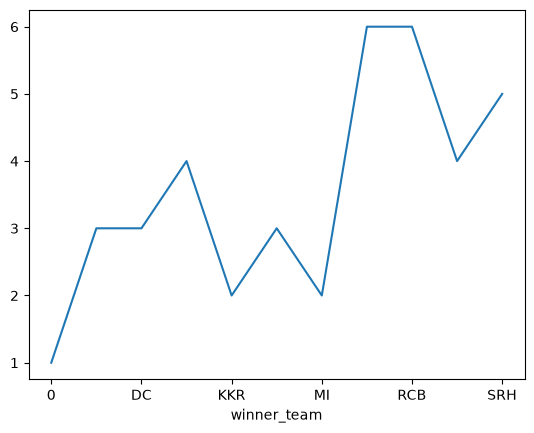

In [6]:
wins = ipl["match_winner"].value_counts()
wins[wins == wins.max()].index

wins = ipl.groupby("match_winner")["match_winner"].count()
wins[wins == wins.max()]
wins.plot()
plt.xlabel("winner_team")

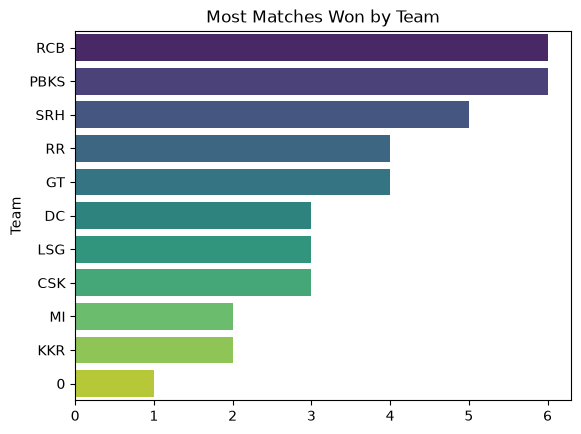

In [7]:
match_wins = ipl['match_winner'].value_counts()

sns.barplot(
    y=match_wins.index,
    x=match_wins.values,
    hue=match_wins.index,
    palette="viridis",
    legend=False
)

plt.title("Most Matches Won by Team")
plt.ylabel("Team")
plt.show()


C:\Users\Aman\AppData\Local\Temp\ipykernel_27548\1053829593.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x= ipl['toss_decision'],palette="rainbow")


<Axes: xlabel='toss_decision', ylabel='count'>

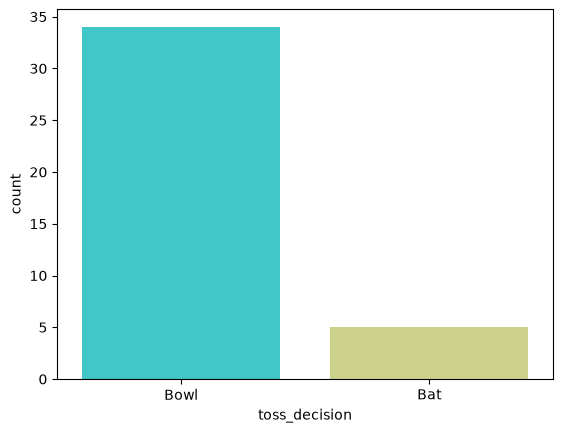

In [8]:
# 2. Toss Decision Trends
ipl.head()
sns.countplot(x= ipl['toss_decision'],palette="rainbow")

In [9]:
# Toss winner vs Match Winner
winner = ipl[ipl["toss_winner"] == ipl["match_winner"]].shape[0]
percentage = (winner / ipl.shape[0]) * 100

print(f"Toss winner also won the match: {percentage:.2f}%")
# teams Name 
ipl[["toss_winner","match_winner"]]


Toss winner also won the match: 53.85%


,toss_winner,match_winner
0,RCB,RCB
1,MI,MI
2,RR,RR
3,PBKS,PBKS
4,DC,DC
5,KKR,SRH
6,PBKS,PBKS
7,DC,DC
8,RR,RR
9,LSG,LSG


Wins by wickets: 61.54%
Wins by runs: 43.59%


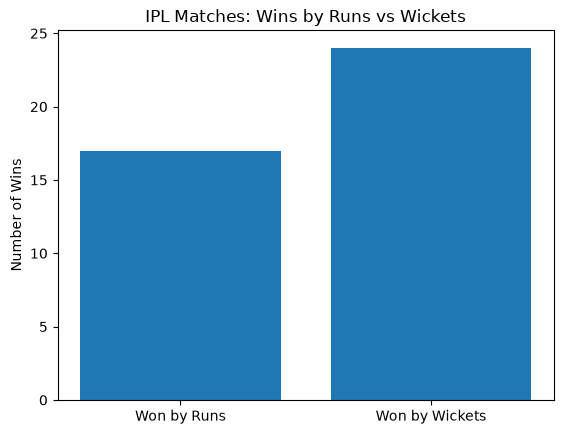

In [10]:
# 4. how do teams wins?(Runs vs Wickets)
# Wins by wickets
wins_by_wickets = ipl[ipl["wb_runs"] == 0.0]["match_id"].count()

# Wins by runs
wins_by_runs = ipl[ipl["wb_wickets"] == 0.0]["match_id"].count()

total_matches = ipl["match_id"].count()

print(f"Wins by wickets: {(wins_by_wickets / total_matches) * 100:.2f}%")
print(f"Wins by runs: {(wins_by_runs / total_matches) * 100:.2f}%")

# Graph
categories = ["Won by Runs", "Won by Wickets"]
wins = [wins_by_runs, wins_by_wickets]

plt.bar(categories, wins)
plt.xticks([0, 1], ["Won by Runs", "Won by Wickets"])
plt.ylabel("Number of Wins")
plt.title("IPL Matches: Wins by Runs vs Wickets")
plt.show()


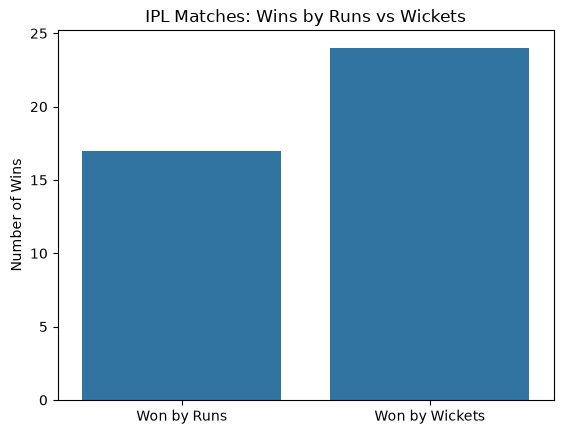

In [11]:
# DO same graph by sns
import seaborn as sns
import matplotlib.pyplot as plt

categories = ["Won by Runs", "Won by Wickets"]
wins = [wins_by_runs, wins_by_wickets]

sns.barplot(x=categories, y=wins)


plt.ylabel("Number of Wins")
plt.title("IPL Matches: Wins by Runs vs Wickets")
plt.show()

### Key Player performances

In [12]:
# 1. Most "Player of the Match" Awards
count_of_player = ipl["player_of_the_match"].groupby(ipl["player_of_the_match"]).count()
Man_of_the_mathc = count_of_player[count_of_player == max(count_of_player)]
Man_of_the_mathc


player_of_the_match
Josh Hazlewood    2
Priyansh Arya     2
Sameer Rizvi      2
Sanju Samson      2
Name: player_of_the_match, dtype: int64

In [13]:
count_of_player = ipl["player_of_the_match"].value_counts() # gives in ascending order
ipl[ipl["player_of_the_match"].isin(count_of_player[count_of_player == count_of_player.max()].index)]

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_winner,wb_runs,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match
4,5,"April 01, 2026","Ekana Cricket Stadium, Lucknow",LSG,DC,League,DC,Bowl,141.0,10.0,...,DC,0.0,6.0,17.0,Sameer Rizvi,Sameer Rizvi,70.0,Lungi Ngidi,3--27,No
6,7,"April 03, 2026","MA Chidambaram Stadium, Chennai",CSK,PBKS,League,PBKS,Bowl,209.0,5.0,...,PBKS,0.0,5.0,8.0,Priyansh Arya,Ayush Matre,73.0,Vijaykumar Vyshak,2--38,No
7,8,"April 04, 2026","Arun Jaitley Stadium, Delhi",DC,MI,League,DC,Bowl,162.0,6.0,...,DC,0.0,6.0,11.0,Sameer Rizvi,Sameer Rizvi,90.0,Mukesh Kumar,2--26,No
17,18,"April 11, 2026","MA Chidambaram Stadium, Chennai",CSK,DC,League,DC,Bowl,212.0,2.0,...,CSK,23.0,0.0,0.0,Sanju Samson,Sanju Samson,115.0,Jamie Overton,4--18,No
22,23,"April 15, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,LSG,League,RCB,Bowl,146.0,10.0,...,RCB,0.0,5.0,29.0,Josh Hazlewood,Virat Kohli,49.0,Rasikh Salam,4--24,No
28,29,"April 19, 2026","New PCA Cricket Stadium, Mullanpur",PBKS,LSG,League,LSG,Bowl,254.0,7.0,...,PBKS,54.0,0.0,0.0,Priyansh Arya,Priyansh Arya,93.0,Prince Yadav,2--25,No
32,33,"April 23, 2026","Wankhede Stadium, Mumbai",MI,CSK,League,MI,Bowl,207.0,6.0,...,CSK,103.0,0.0,6.0,Sanju Samson,Sanju Samson,101.0,Akeal Hosein,4--17,No
38,39,"April 27, 2026","Arun Jaitley Stadium, Delhi",DC,RCB,League,RCB,Bowl,75.0,10.0,...,RCB,0.0,9.0,81.0,Josh Hazlewood,Devdutt Padikkal,34.0,Josh Hazlewood,4--12,No


C:\Users\Aman\AppData\Local\Temp\ipykernel_27548\1017902212.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x= count_of_player.values, y=count_of_player.index,palette="mako")


Text(0.5, 1.0, 'top 10 player man of matches')

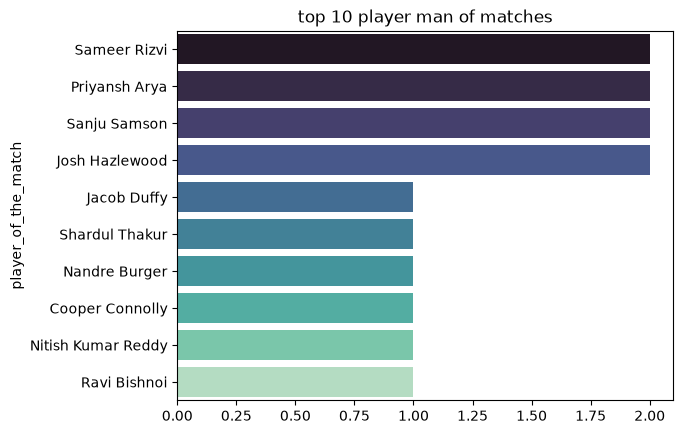

In [14]:
count_of_player = ipl["player_of_the_match"].value_counts().head(10)
sns.barplot(x= count_of_player.values, y=count_of_player.index,palette="mako")
plt.title("top 10 player man of matches")

In [15]:
# 2 Top Scores in single match 

ipl.head()
high_scrore = ipl.sort_values("highscore", ascending=False).head(2)
high_scrore[["player_of_the_match", "highscore"]]



,player_of_the_match,highscore
34,KL Rahul,152.0
30,Abhishek Sharma,135.0


In [16]:
ipl.head(2)
score = ipl.groupby("top_scorer")['highscore'].sum().sort_values(ascending=False).head(2)
score


top_scorer
Abhishek Sharma    268.0
Sanju Samson       264.0
Name: highscore, dtype: float64

<Axes: xlabel='top_scorer'>

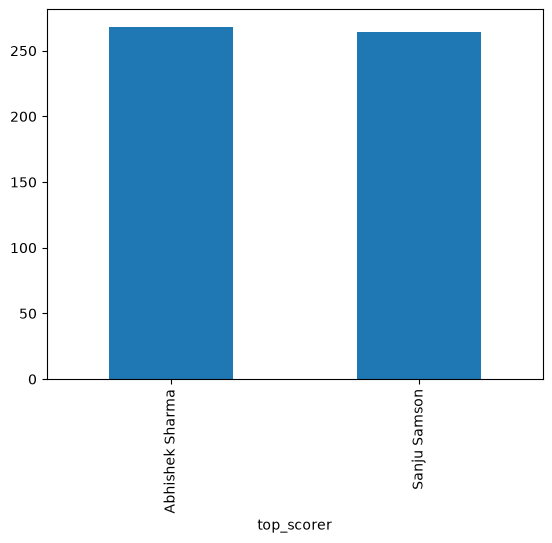

In [17]:
score.plot(kind = 'bar')

In [18]:
sns.barplot(data=score, x="top_scorer", y="highscore", hue="top_scorer",palette="rainbow")

TypeError: Data source must be a DataFrame or Mapping, not <class 'pandas.Series'>.

In [ ]:
# Ten best Bolling Figure
ipl.head(2)
ipl["bowling_wickets"] = (
    ipl["best_bowling_figure"]
    .str.split("--")
    .str[0]
    .astype(float)
)
ipl[["best_bowling", "best_bowling_figure", "bowling_wickets"]] \
    .sort_values("bowling_wickets", ascending=False) \
    .head(10)

,best_bowling,best_bowling_figure,bowling_wickets
37,Mohsin Khan,5--23,5.0
5,Blessing Muzarabani,4--41,4.0
22,Rasikh Salam,4--24,4.0
17,Jamie Overton,4--18,4.0
8,Ravi Bishnoi,4--41,4.0
20,Sakib Hussain,4--24,4.0
30,Eshan Malinga,4--32,4.0
38,Josh Hazlewood,4--12,4.0
29,Ashwani Kumar,4--24,4.0
18,Prasidh Krishna,4--28,4.0


In [ ]:
# 3 best bowler
ipl["wickets"] = ipl["best_bowling_figure"].str.split("--").str[0].astype(float)
ipl["runs"] = ipl["best_bowling_figure"].str.split("--").str[1].astype(float)
best_bowler = ipl.sort_values(
    ["wickets", "runs"],
    ascending=[False, True]
).iloc[0:3]["best_bowling"]

print(best_bowler)

37       Mohsin Khan
38    Josh Hazlewood
32      Akeal Hosein
Name: best_bowling, dtype: object


In [ ]:
# with Figure
top_3 = ipl.sort_values(
    ["wickets", "runs"],
    ascending=[False, True]
)[["best_bowling", "best_bowling_figure"]].head(3)

print(top_3)

      best_bowling best_bowling_figure
37     Mohsin Khan               5--23
38  Josh Hazlewood               4--12
32    Akeal Hosein               4--17


In [22]:
# Another method
# logic:

# Highest wickets → better bowler.
# If wickets are the same, lowest runs conceded → better bowler
ipl["heighest_wicket"] = ipl["best_bowling_figure"].apply(
    lambda x: int(str(x).split("--")[0])
)

ipl["run_on_wicket"] = ipl["best_bowling_figure"].apply(
    lambda x: str(x).split("--")[1] if "--" in str(x) else None
)

top_ten_boller = ipl.sort_values(
    ["heighest_wicket", "run_on_wicket"],
    ascending=[False, True]
)[["best_bowling", "heighest_wicket"]].head(10)

top_bowlers = ipl.groupby("best_bowling")['heighest_wicket'].sum().sort_values(ascending=False)
top_bowlers


best_bowling
Eshan Malinga          7
Jofra Archer           7
Prasidh Krishna        7
Kagiso Rabada          6
Bhuvneshwar Kumar      6
Mohsin Khan            5
Rashid Khan            5
Blessing Muzarabani    4
Jamie Overton          4
Josh Hazlewood         4
Ravi Bishnoi           4
Sakib Hussain          4
Rasikh Salam           4
Ashwani Kumar          4
Akeal Hosein           4
Jacob Duffy            3
Varun Chakravarthy     3
Shivang Kumar          3
Noor Ahmad             3
Shardul Thakur         3
Lungi Ngidi            3
Arshdeep Singh         3
Anukul Roy             2
Krunal Pandya          2
Prince Yadav           2
Kuldeep Yadav          2
Mohammed Shami         2
Mukesh Kumar           2
Suyash Sharma          2
Sandeep Sharma         2
Vijaykumar Vyshak      2
0                      0
Name: heighest_wicket, dtype: int64

C:\Users\Aman\AppData\Local\Temp\ipykernel_18744\95698658.py:10: UserWarning: Glyph 127951 (\N{CRICKET BAT AND BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Aman\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127951 (\N{CRICKET BAT AND BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


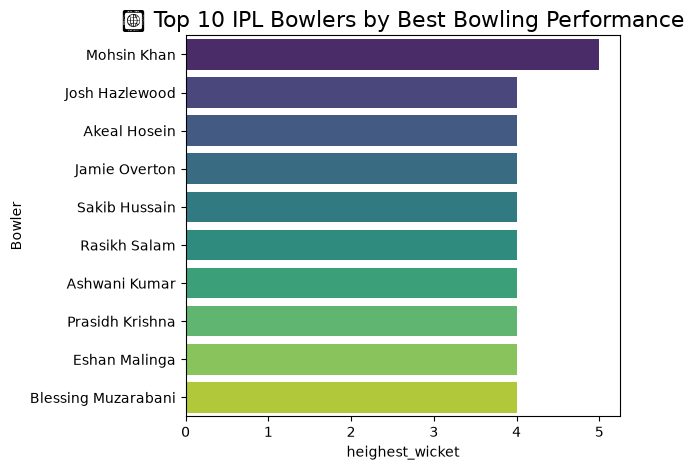

In [ ]:
sns.barplot(data=top_ten_boller,x="heighest_wicket",
    y="best_bowling",
    hue="best_bowling",
    palette="viridis",
    legend=False
)
plt.title("🏏 Top 10 IPL Bowlers by Best Bowling Performance", fontsize=16)

plt.ylabel("Bowler")
plt.tight_layout()
plt.show()

C:\Users\Aman\AppData\Local\Temp\ipykernel_18744\1985743695.py:18: UserWarning: Glyph 127951 (\N{CRICKET BAT AND BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Aman\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127951 (\N{CRICKET BAT AND BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


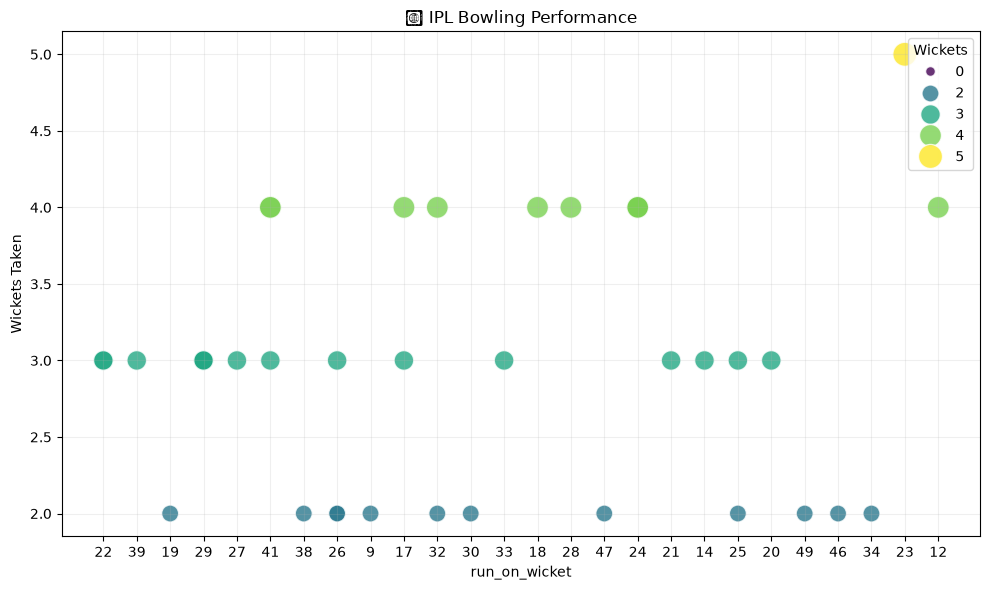

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=ipl,
    x="run_on_wicket",
    y="heighest_wicket",
    size="heighest_wicket",
    hue="heighest_wicket",
    palette="viridis",
    sizes=(50, 300),
    alpha=0.8
)

plt.title("🏏 IPL Bowling Performance")
plt.ylabel("Wickets Taken")
plt.legend(title="Wickets")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
#Value Analysis
ipl.head(2)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match,heighest_wicket,run_on_wicket
0,1,"March 28, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,SRH,League,RCB,Bowl,201.0,9.0,...,6.0,26.0,Jacob Duffy,Ishan Kishan,80.0,Jacob Duffy,3--22,No,3,22
1,2,"March 29, 2026","Wankhede Stadium, Mumbai",MI,KKR,League,MI,Bowl,220.0,4.0,...,6.0,5.0,Shardul Thakur,Ryan Rickelton,81.0,Shardul Thakur,3--39,No,3,39


C:\Users\Aman\AppData\Local\Temp\ipykernel_27548\957761846.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y= Most_venue.index,x = Most_venue.values,palette="rainbow")


<Axes: ylabel='venue'>

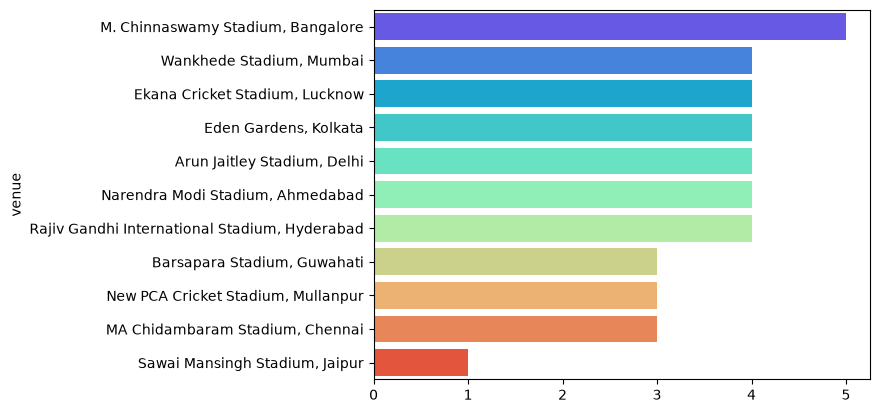

In [43]:
Most_venue = ipl["venue"].value_counts()
sns.barplot(y= Most_venue.index,x = Most_venue.values,palette="rainbow")

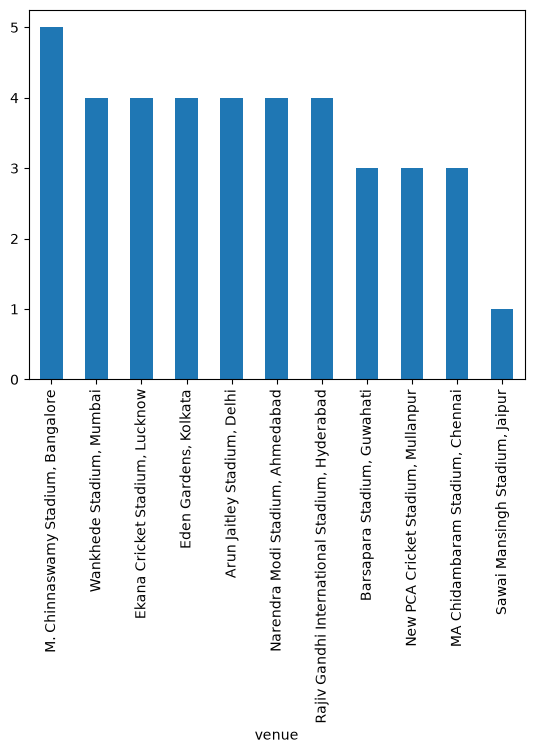

In [40]:
Most_venue.plot(kind="bar")
plt.show()

In [ ]:
ipl.head(2)
ipl["wb"]

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match,heighest_wicket,run_on_wicket
0,1,"March 28, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,SRH,League,RCB,Bowl,201.0,9.0,...,6.0,26.0,Jacob Duffy,Ishan Kishan,80.0,Jacob Duffy,3--22,No,3,22
1,2,"March 29, 2026","Wankhede Stadium, Mumbai",MI,KKR,League,MI,Bowl,220.0,4.0,...,6.0,5.0,Shardul Thakur,Ryan Rickelton,81.0,Shardul Thakur,3--39,No,3,39


### self Made Question
1. Who won heighest margin by run


In [76]:
Hei = ipl[["match_winner","wb_runs"]].sort_values(by= "wb_runs",ascending=False).rename(columns={"match_winner": "Team_name", "wb_runs": "Runs"}).head(1)
Hei

,Team_name,Runs
32,CSK,103.0
